
Processing: Collinder 69


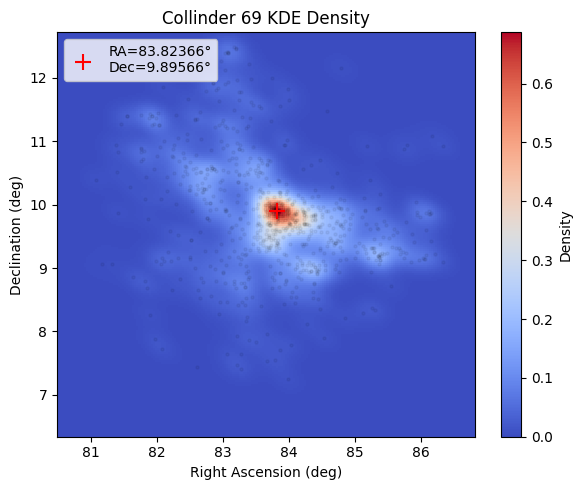


Processing: Collinder 261


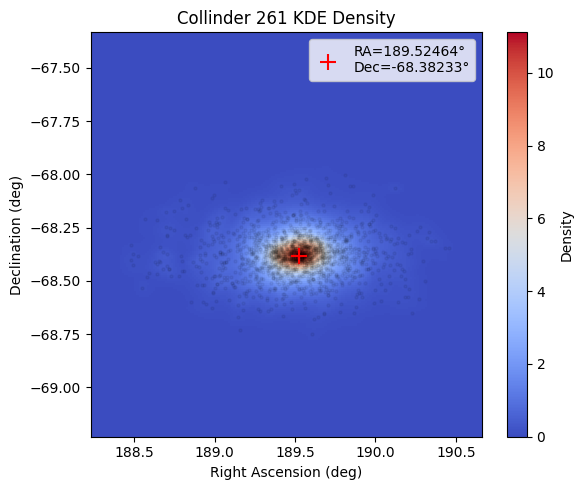


Processing: IC 4651


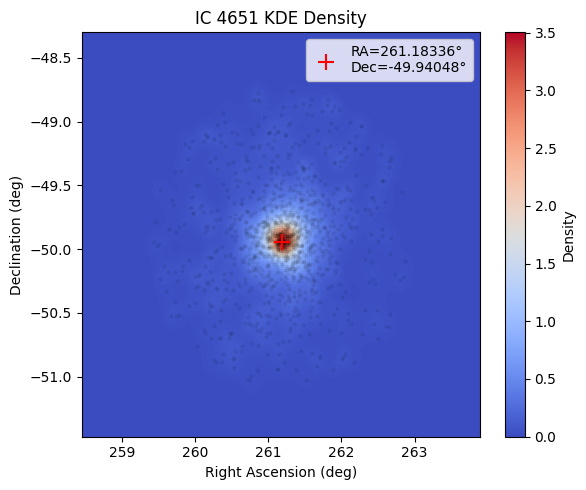


Processing: Melotte 20


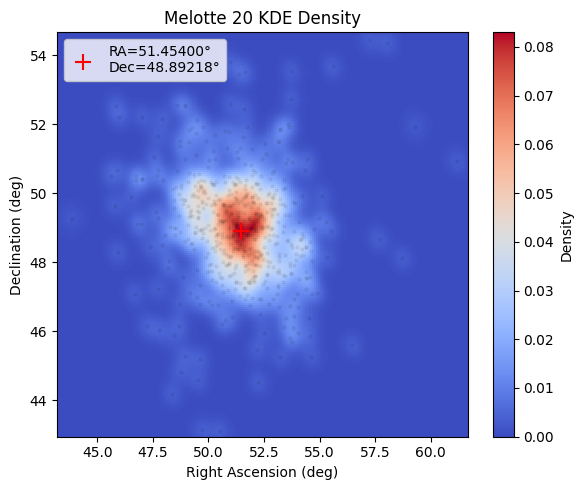


Processing: Melotte 22


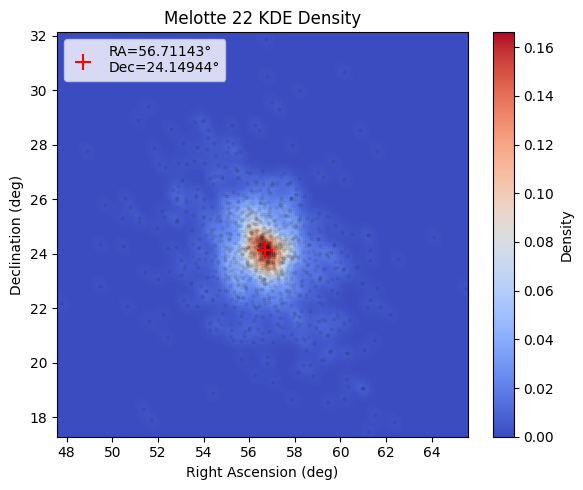


Processing: Melotte 101


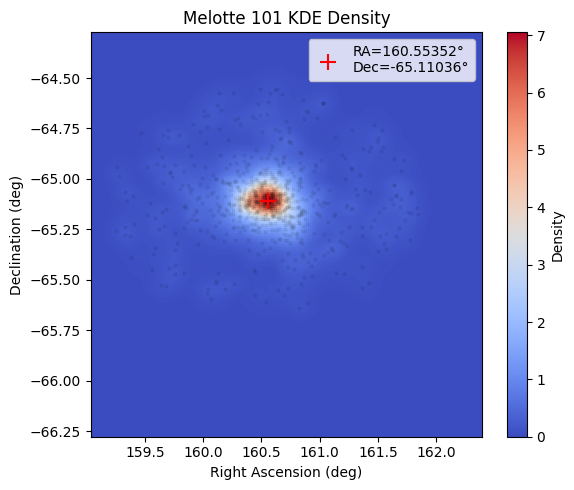


Processing: NGC 188


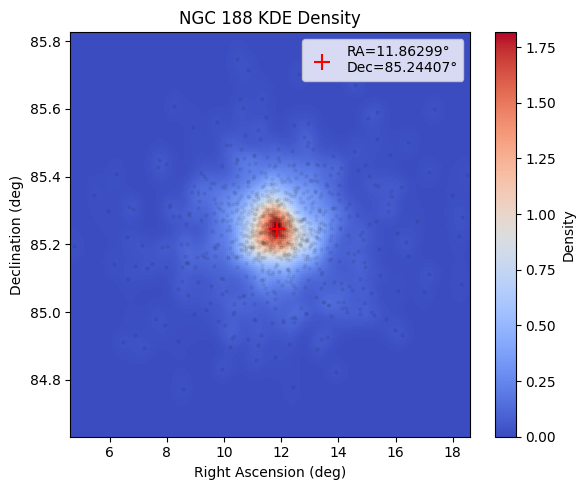


Processing: NGC 1039


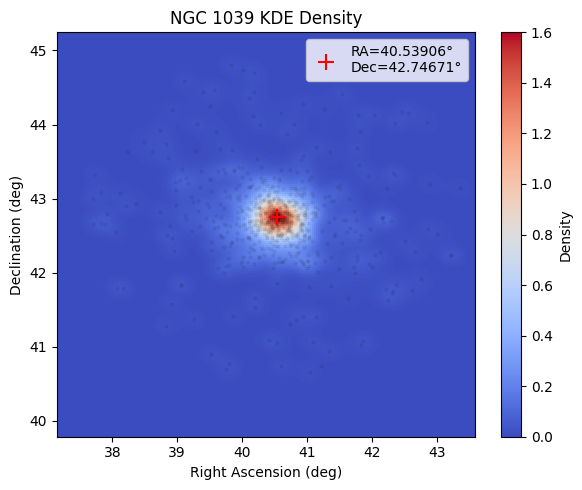


Processing: NGC 1647


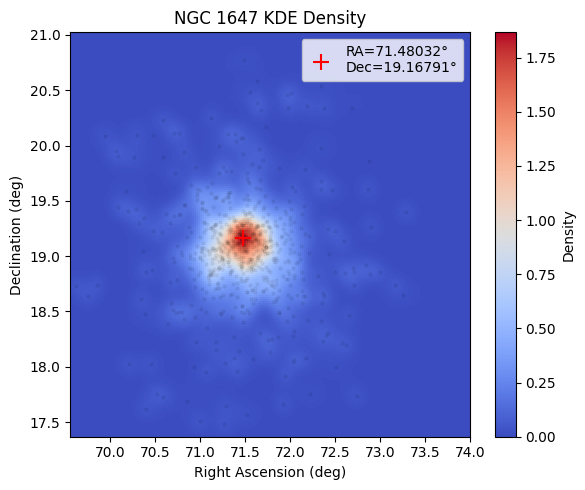


Processing: NGC 2112


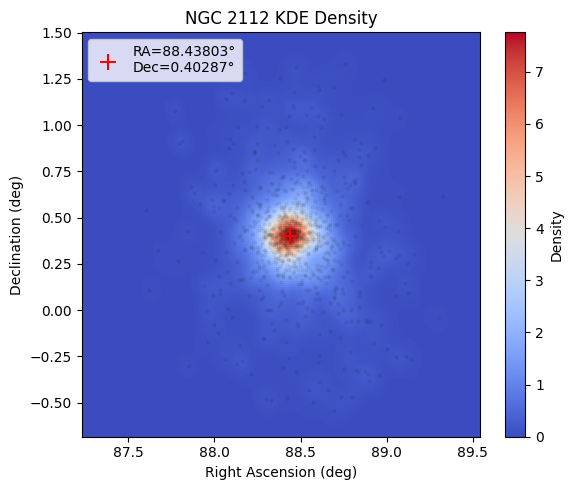


Processing: NGC 2287


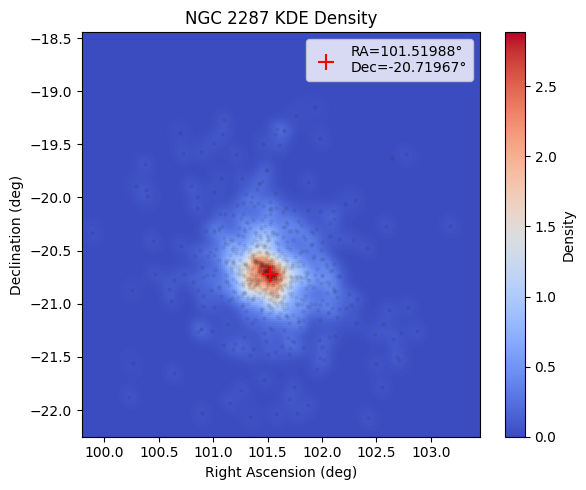


Processing: NGC 2477


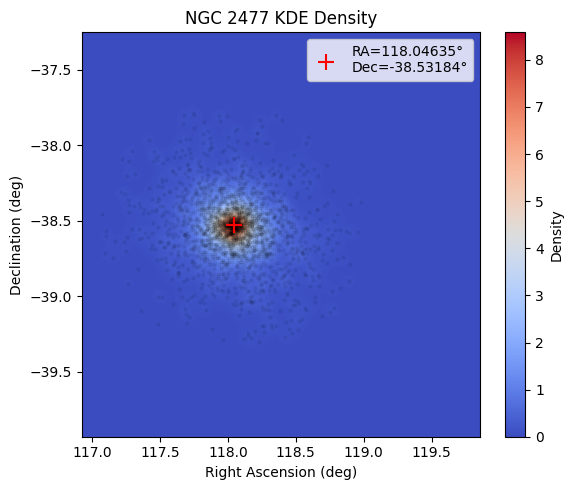


Processing: NGC 2516


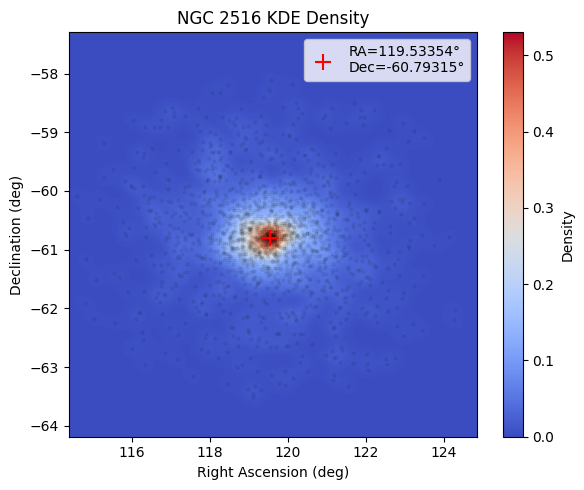


Processing: NGC 2539


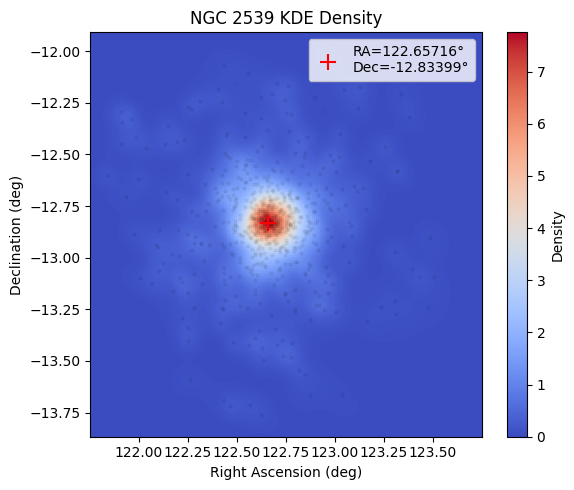


Processing: NGC 2632


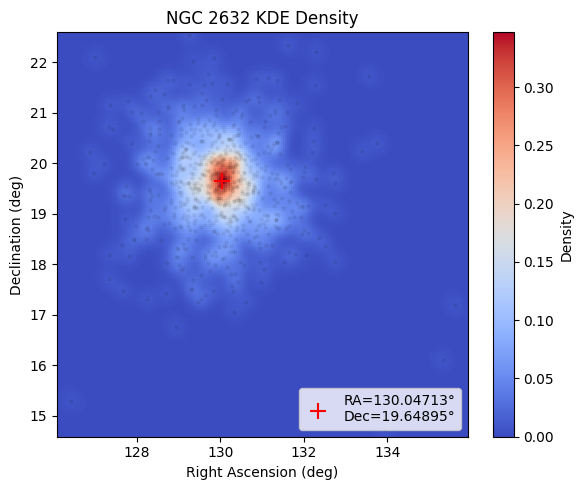


Processing: NGC 2682


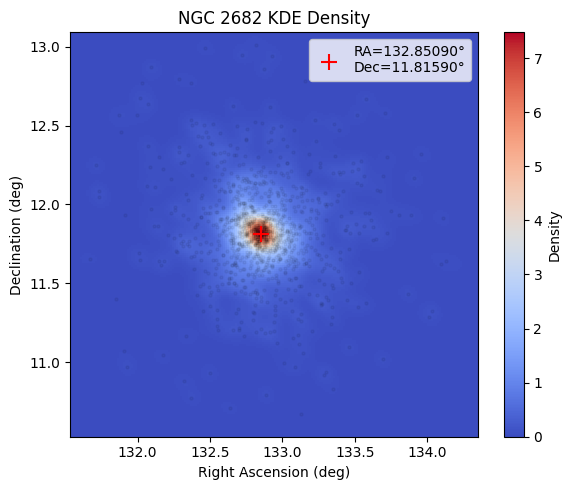


Processing: NGC 6124


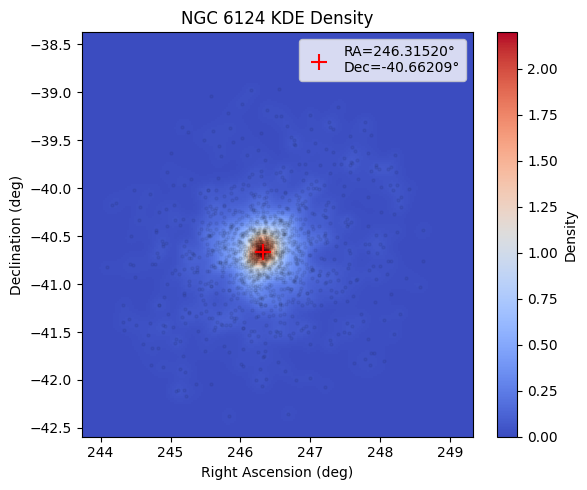


Processing: NGC 6819


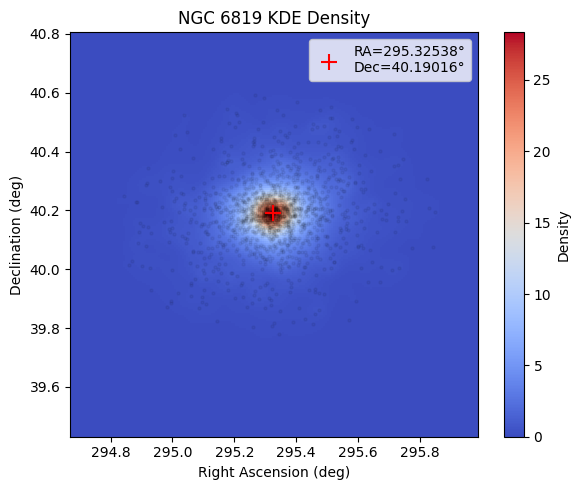


Processing: NGC 6939


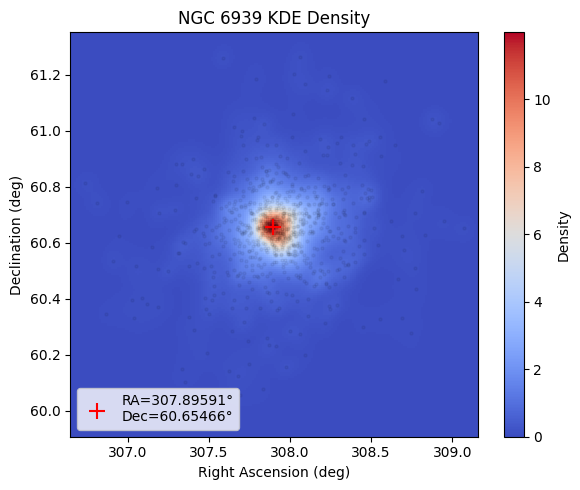


Processing: NGC 6940


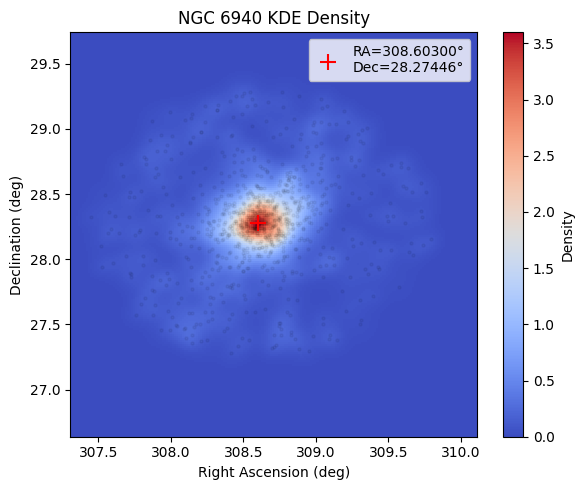


Processing: NGC 7789


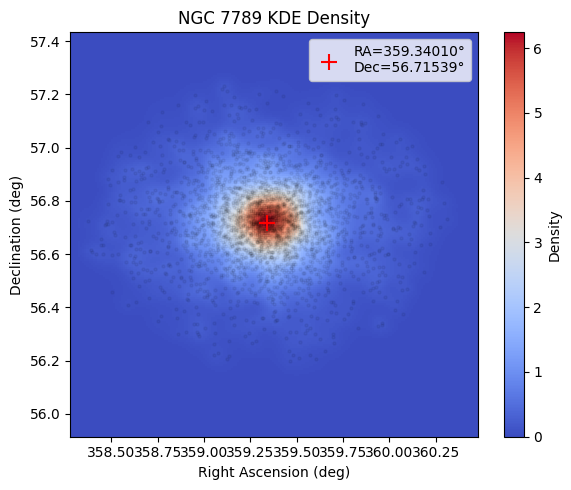


Cluster centres:
          Cluster  RA_KDE_deg  Dec_KDE_deg  Members
0    Collinder 69   83.823656     9.895662      787
1   Collinder 261  189.524645   -68.382326     1910
2         IC 4651  261.183364   -49.940483     1360
3      Melotte 20   51.453997    48.892177      583
4      Melotte 22   56.711431    24.149442     1269
5     Melotte 101  160.553516   -65.110363      810
6         NGC 188   11.862991    85.244072      905
7        NGC 1039   40.539057    42.746706      711
8        NGC 1647   71.480319    19.167910      688
9        NGC 2112   88.438035     0.402865      867
10       NGC 2287  101.519882   -20.719667      679
11       NGC 2477  118.046354   -38.531842     2696
12       NGC 2516  119.533543   -60.793147     1874
13       NGC 2539  122.657157   -12.833992      570
14       NGC 2632  130.047128    19.648946      730
15       NGC 2682  132.850897    11.815897     1178
16       NGC 6124  246.315201   -40.662093     1501
17       NGC 6819  295.325381    40.190156    

In [9]:
# ===============================================================
# OPEN CLUSTER CENTRE ESTIMATION PIPELINE
# Monte-Carlo propagation of astrometric errors + KDE peak
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import os


# ===============================================================
# CLUSTER MEMBER FILES
# ===============================================================

cluster_files = {

"Collinder 69": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Collinder_69_final (1).csv",
"Collinder 261": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Collinder_261_final.csv",
"IC 4651": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/IC_4651_final.csv",
"Melotte 20": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Melotte_20_final.csv",
"Melotte 22": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Melotte_22_final.csv",
"Melotte 101": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Melotte_101_final.csv",
"NGC 188": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_188_final.csv",
"NGC 1039": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_1039_final.csv",
"NGC 1647": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_1647_final.csv",
"NGC 2112": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2112_final.csv",
"NGC 2287": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2287_final.csv",
"NGC 2477": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2477_final.csv",
"NGC 2516": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2516_final.csv",
"NGC 2539": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2539_final.csv","NGC 2632": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2632_final.csv",
"NGC 2682": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2682_final.csv",
"NGC 6124": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6124_final.csv",
"NGC 6819": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6819_final.csv",
"NGC 6939": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6939_final.csv",
"NGC 6940": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6940_final.csv",
"NGC 7789": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_7789_final.csv"
}


# ===============================================================
# CORRELATION FILES
# ===============================================================

corr_files = {

"Collinder 69": "/Users/prernadwivedi/Downloads/21 clusters/corr_collinder_69.csv",
"Collinder 261": "/Users/prernadwivedi/Downloads/21 clusters/corr_collinder_261.csv",
"IC 4651": "/Users/prernadwivedi/Downloads/21 clusters/corr_IC4651.csv",
"Melotte 20": "/Users/prernadwivedi/Downloads/21 clusters/corr_Melotte20.csv",
"Melotte 22": "/Users/prernadwivedi/Downloads/21 clusters/corr_Melotte22.csv",
"Melotte 101": "/Users/prernadwivedi/Downloads/21 clusters/corr_Melotte101.csv",
"NGC 188": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC188.csv",
"NGC 1039": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC1039.csv",
"NGC 1647": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC1647.csv",
"NGC 2112": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC2112.csv",
"NGC 2287": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC2287.csv",
"NGC 2477": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC2477.csv",
"NGC 2516": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC2516.csv",
"NGC 2539": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC2539.csv",
"NGC 2632": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC2632.csv",
"NGC 2682": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC2682.csv",
"NGC 6124": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC6124.csv",
"NGC 6819": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC6819.csv",
"NGC 6939": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC6939.csv",
"NGC 6940": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC6940.csv",
"NGC 7789": "/Users/prernadwivedi/Downloads/21 clusters/corr_NGC7789.csv"
}


# ===============================================================
# MEMBERSHIP THRESHOLDS
# ===============================================================

membership_thresholds = {
"Collinder 69":0.9,
"Collinder 261":0.93,
"IC 4651":0.97,
"Melotte 20":0.94,
"Melotte 22":0.95,
"Melotte 101":0.95,
"NGC 188":0.95,
"NGC 1039":0.94,
"NGC 1647":0.94,
"NGC 2112":0.95,
"NGC 2287":0.96,
"NGC 2477":0.94,
"NGC 2516":0.95,
"NGC 2539":0.96,
"NGC 2632":0.93,
"NGC 2682":0.93,
"NGC 6124":0.95,
"NGC 6819":0.95,
"NGC 6939":0.96,
"NGC 6940":0.95,
"NGC 7789":0.92
}


# ===============================================================
# MONTE CARLO SAMPLING
# ===============================================================

def sample_positions_with_errors(star_dict,size=100):

    ra_samples=[]
    dec_samples=[]

    for i in star_dict.keys():

        mean=[star_dict[i]["ra"],star_dict[i]["dec"]]
        cov=star_dict[i]["cov"]

        try:
            samples=np.random.multivariate_normal(mean,cov,size=size)
        except:
            continue

        ra_samples.append(samples[:,0])
        dec_samples.append(samples[:,1])

    if len(ra_samples)==0:
        return np.array([]),np.array([])

    return np.concatenate(ra_samples),np.concatenate(dec_samples)


# ===============================================================
# STORAGE
# ===============================================================

centre_results=[]


# ===============================================================
# MAIN LOOP
# ===============================================================

for cluster_name,csv_path in cluster_files.items():

    print("\nProcessing:",cluster_name)

    df=pd.read_csv(csv_path)

    # detect source id column
    if "Source" in df.columns:
        id_col="Source"
    elif "source_id" in df.columns:
        id_col="source_id"
    elif "col1" in df.columns:
        id_col="col1"
    else:
        raise ValueError("No Gaia source id column found")

    # load correlation table
    corr_df=pd.read_csv(corr_files[cluster_name])

    if "source_id" in corr_df.columns:
        corr_df=corr_df.rename(columns={"source_id":id_col})

    df=df.merge(corr_df,on=id_col,how="left")
    df["ra_dec_corr"]=df["ra_dec_corr"].fillna(0)

    # membership cut
    df=df[df["cluster_membership"]>membership_thresholds[cluster_name]]

    if len(df)<10:
        continue


    # build covariance matrices
    star_dict={}

    for i,row in df.iterrows():

        ra=row["ra"]
        dec=row["dec"]

        ra_err=max(row["ra_error"],1e-10)
        dec_err=max(row["dec_error"],1e-10)

        rho=np.clip(row["ra_dec_corr"],-1,1)

        cov=np.array([
        [ra_err**2,rho*ra_err*dec_err],
        [rho*ra_err*dec_err,dec_err**2]
        ])

        cov+=np.eye(2)*1e-12

        star_dict[i]={"ra":ra,"dec":dec,"cov":cov}


    # Monte Carlo sampling
    ra_samples,dec_samples=sample_positions_with_errors(star_dict,100)

    if len(ra_samples)==0:
        continue


    # RA wrap fix
    ra_med=np.median(ra_samples)

    ra_samples[ra_samples-ra_med>180]-=360
    ra_samples[ra_samples-ra_med<-180]+=360


    # KDE density
    kde=gaussian_kde(np.vstack([ra_samples,dec_samples]))

    ra_grid=np.linspace(ra_samples.min(),ra_samples.max(),200)
    dec_grid=np.linspace(dec_samples.min(),dec_samples.max(),200)

    RA,DEC=np.meshgrid(ra_grid,dec_grid)

    density=kde(np.vstack([RA.ravel(),DEC.ravel()])).reshape(RA.shape)


    # density peak
    idx=np.unravel_index(np.argmax(density),density.shape)

    ra_center=RA[idx]%360
    dec_center=DEC[idx]


    centre_results.append({
    "Cluster":cluster_name,
    "RA_KDE_deg":ra_center,
    "Dec_KDE_deg":dec_center,
    "Members":len(df)
    })


    # plotting
    plt.figure(figsize=(6,5))

    plt.pcolormesh(RA,DEC,density,cmap="coolwarm",shading="auto")
    plt.colorbar(label="Density")

    ra_plot=df["ra"].copy()
    ra_plot[ra_plot-ra_med>180]-=360
    ra_plot[ra_plot-ra_med<-180]+=360

    plt.scatter(ra_plot,df["dec"],s=5,color="black",alpha=0.05)

    plt.scatter(
    ra_center,
    dec_center,
    color="red",
    s=120,
    marker="+",
    label=f"RA={ra_center:.5f}°\nDec={dec_center:.5f}°"
    )

    plt.xlabel("Right Ascension (deg)")
    plt.ylabel("Declination (deg)")
    plt.title(cluster_name+" KDE Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ===============================================================
# SAVE RESULTS
# ===============================================================

centre_df=pd.DataFrame(centre_results)

centre_df.to_csv("kde_centres_all_clusters.csv",index=False)

print("\nCluster centres:")
print(centre_df)


In [11]:
import pandas as pd

# -------------------------------------------------
# Load centre table produced by KDE pipeline
# -------------------------------------------------

df = pd.read_csv("kde_centres_all_clusters.csv")


# -------------------------------------------------
# Distance dictionary (pc)
# -------------------------------------------------

distance_dict = {
    "NGC 2287": 641,
    "Collinder 261": 2634,
    "Collinder 69": 396,
    "IC 4651": 908,
    "Melotte 101": 1728,
    "Melotte 20": 180,
    "Melotte 22": 150,
    "NGC 1039": 533,
    "NGC 1647": 520,
    "NGC 188": 1746,
    "NGC 2112": 778,
    "NGC 2477": 1263,
    "NGC 2516": 414,
    "NGC 2539": 1176,
    "NGC 2632": 174,
    "NGC 2682": 501,
    "NGC 6124": 501,
    "NGC 6819": 2056,
    "NGC 6939": 1422,
    "NGC 6940": 1061,
    "NGC 7789": 1421
}


# -------------------------------------------------
# Membership threshold dictionary
# -------------------------------------------------

membership_thresholds = {
    "Collinder 69":0.9,
    "Collinder 261":0.93,
    "IC 4651":0.97,
    "Melotte 20":0.94,
    "Melotte 22":0.95,
    "Melotte 101":0.95,
    "NGC 188":0.95,
    "NGC 1039":0.94,
    "NGC 1647":0.94,
    "NGC 2112":0.95,
    "NGC 2287":0.96,
    "NGC 2477":0.94,
    "NGC 2516":0.95,
    "NGC 2539":0.96,
    "NGC 2632":0.93,
    "NGC 2682":0.93,
    "NGC 6124":0.95,
    "NGC 6819":0.95,
    "NGC 6939":0.96,
    "NGC 6940":0.95,
    "NGC 7789":0.92
}


# -------------------------------------------------
# Rename Members column
# -------------------------------------------------

df = df.rename(columns={"Members": "Members_after_cut"})


# -------------------------------------------------
# Add distance column
# -------------------------------------------------

df["distance_pc"] = df["Cluster"].map(distance_dict)


# -------------------------------------------------
# Add membership threshold column
# -------------------------------------------------

df["Membership_threshold"] = df["Cluster"].map(membership_thresholds)


# -------------------------------------------------
# Reorder columns
# -------------------------------------------------

df = df[
    [
        "Cluster",
        "RA_KDE_deg",
        "Dec_KDE_deg",
        "Members_after_cut",
        "Membership_threshold",
        "distance_pc"
    ]
]


# -------------------------------------------------
# Save final CSV
# -------------------------------------------------

df.to_csv("cluster_centres_with_distance.csv", index=False)


print("Saved file: cluster_centres_with_distance.csv")
print(df)


Saved file: cluster_centres_with_distance.csv
          Cluster  RA_KDE_deg  Dec_KDE_deg  Members_after_cut  \
0    Collinder 69   83.823656     9.895662                787   
1   Collinder 261  189.524645   -68.382326               1910   
2         IC 4651  261.183364   -49.940483               1360   
3      Melotte 20   51.453997    48.892177                583   
4      Melotte 22   56.711431    24.149442               1269   
5     Melotte 101  160.553516   -65.110363                810   
6         NGC 188   11.862991    85.244072                905   
7        NGC 1039   40.539057    42.746706                711   
8        NGC 1647   71.480319    19.167910                688   
9        NGC 2112   88.438035     0.402865                867   
10       NGC 2287  101.519882   -20.719667                679   
11       NGC 2477  118.046354   -38.531842               2696   
12       NGC 2516  119.533543   -60.793147               1874   
13       NGC 2539  122.657157   -12.833992  